# Regularization_in_Neural_Networks

# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from mlxtend.plotting import plot_decision_regions

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score

In [4]:
from keras import Sequential
from keras.layers import Dense, Input, Dropout
from keras.optimizers import SGD, Adam
from keras.activations import sigmoid
from keras.losses import BinaryCrossentropy

from keras import regularizers

# Make Dataset

In [5]:
X, y = make_moons(100, noise=0.25,random_state=2)

## Plot Dataset

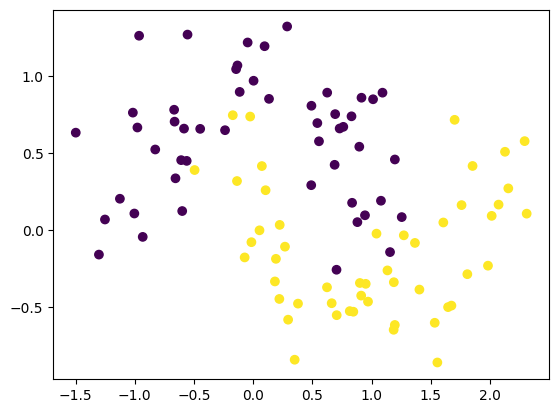

In [6]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

# Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Model

In [8]:
model1 = Sequential()
model1.add(Input(shape=(2,)))

model1.add(Dense(512, activation='relu'))
model1.add(Dense(512, activation='relu'))

model1.add(Dense(1, activation='sigmoid'))

In [9]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,705 (1.01 MB)

 Trainable params: 264,705 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

## Model Compile

In [10]:
model1.compile(
    loss=BinaryCrossentropy(),
    optimizer=Adam(learning_rate=0.01),
    metrics=['accuracy']
)

## Model Training

In [11]:
history1 = model1.fit(
    x=X,
    y=y,
    epochs=3000,
    batch_size=10,
    validation_data=(X_test, y_test),
    verbose=0
)

## Plot Data

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step


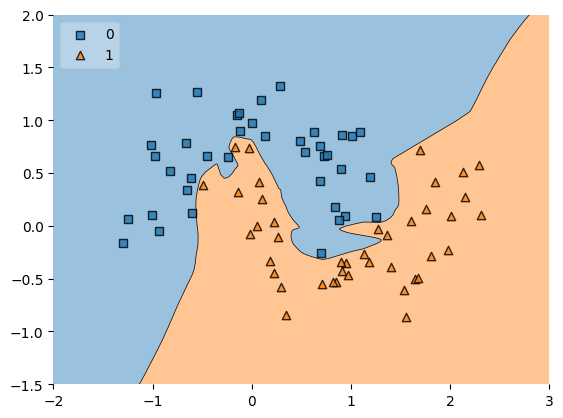

In [12]:
plot_decision_regions(X_train, y_train.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

## Loss Plot

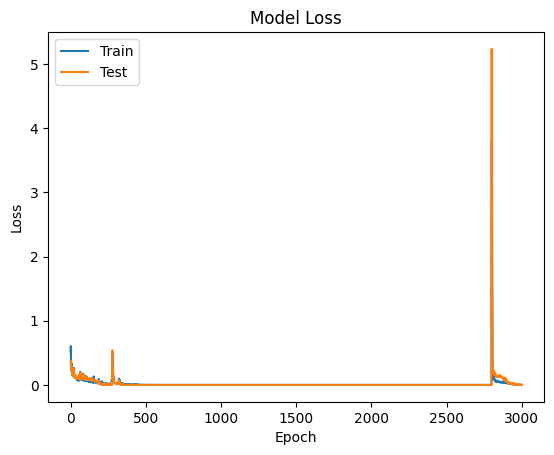

In [13]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

## Accuracy Plot

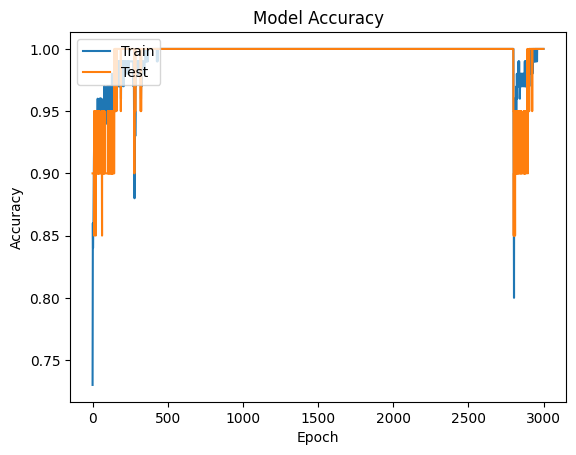

In [14]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Regularization L2

```Python
layer = layers.Dense(
    units=64,
    kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4),
    bias_regularizer=regularizers.L2(1e-4),
    activity_regularizer=regularizers.L2(1e-5)
)
```

## Model Build

In [15]:
model2 = Sequential()
model2.add(Input(shape=(2,)))

model2.add(Dense(512, activation='relu', kernel_regularizer=regularizers.L2(0.01)))
model2.add(Dense(512, activation='relu', kernel_regularizer=regularizers.L2(0.1)))

model2.add(Dense(1, activation='sigmoid'))

In [16]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,705 (1.01 MB)

 Trainable params: 264,705 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

## Model Compile

In [17]:
model2.compile(
    loss=BinaryCrossentropy(),
    optimizer=Adam(learning_rate=0.1),
    metrics=['accuracy']
)

## Model Training

In [18]:
history2 = model2.fit(
    x=X_train,
    y=y_train,
    epochs=3000,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=0
)

## Plot Data

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step


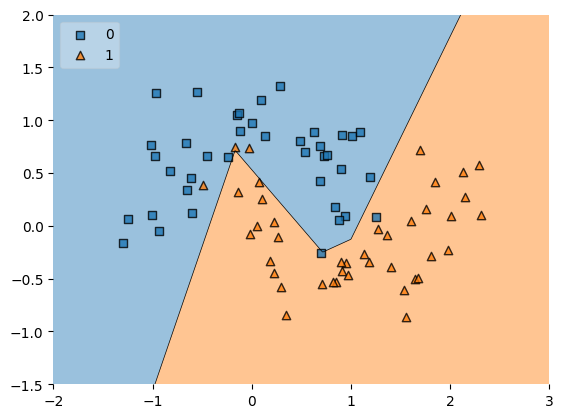

In [19]:
plot_decision_regions(X_train, y_train.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

## Loss Plot

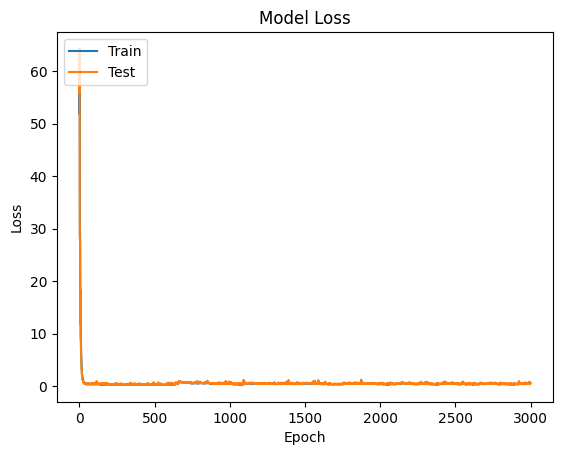

In [20]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

## Accuracy Plot

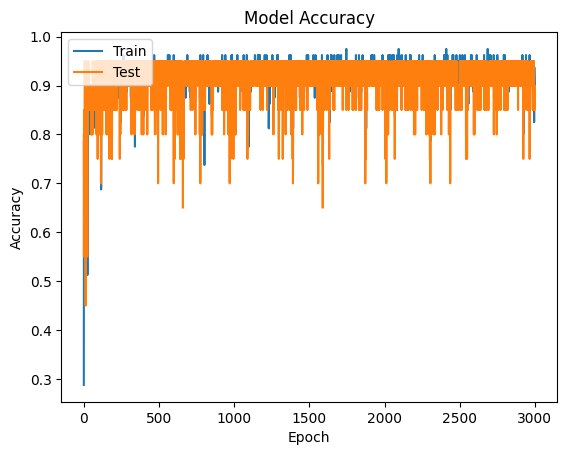

In [21]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# `L1` Regularization

## Model Build

In [22]:
model3 = Sequential()
model3.add(Input(shape=(2,)))

model3.add(Dense(512, activation='relu', kernel_regularizer=regularizers.L1(0.01)))
model3.add(Dense(512, activation='relu', kernel_regularizer=regularizers.L1(0.1)))

model3.add(Dense(1, activation='sigmoid'))

In [23]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,705 (1.01 MB)

 Trainable params: 264,705 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

## Model Compile

In [24]:
model3.compile(
    loss=BinaryCrossentropy(),
    optimizer=Adam(learning_rate=0.1),
    metrics=['accuracy']
)

## Model Training

In [25]:
history3 = model3.fit(
    x=X_train,
    y=y_train,
    epochs=3000,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=0
)

## Plot Data

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step


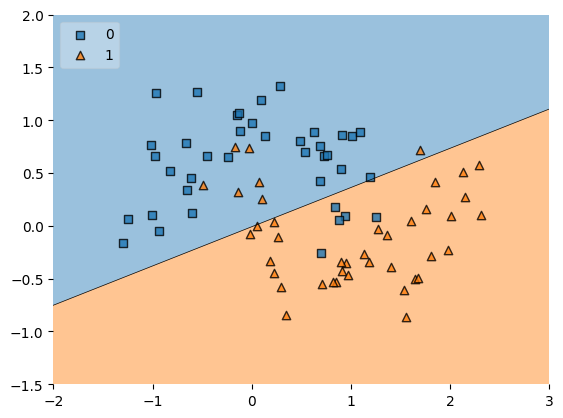

In [26]:
plot_decision_regions(X_train, y_train.astype('int'), clf=model3, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

## Loss Plot

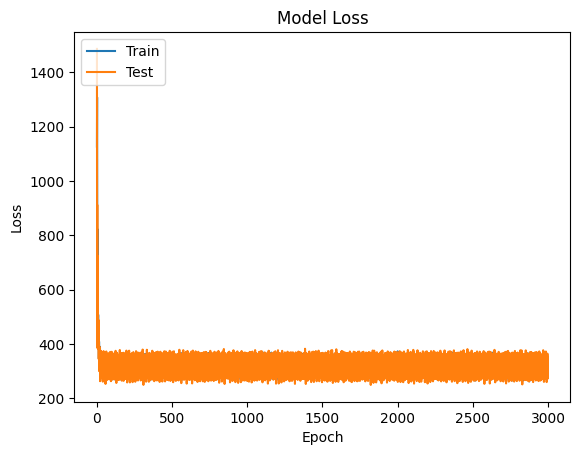

In [27]:
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

## Accuracy Plot

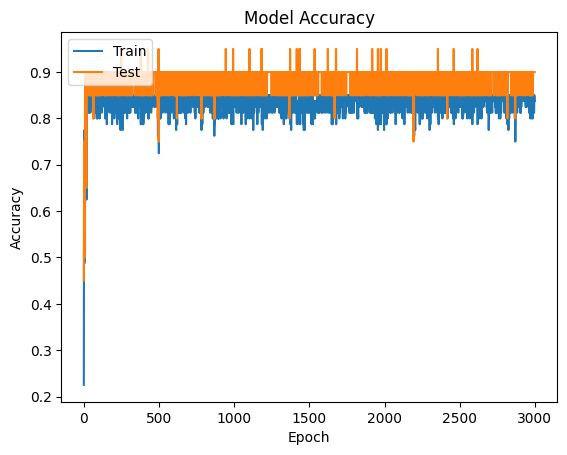

In [28]:
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# `L1` + `L2` Regularization

## Model Build

In [29]:
model4 = Sequential()
model4.add(Input(shape=(2,)))

model4.add(Dense(512, activation='relu', kernel_regularizer=regularizers.L1L2(l1=0.001, l2=0.01)))
model4.add(Dense(512, activation='relu', kernel_regularizer=regularizers.L1L2(l1=0.001, l2=0.01)))

model4.add(Dense(1, activation='sigmoid'))

## Model Compile

In [30]:
model4.compile(
    loss=BinaryCrossentropy(),
    optimizer=Adam(learning_rate=0.1),
    metrics=['accuracy']
)

## Model Training

In [31]:
history4 = model4.fit(
    x=X_train,
    y=y_train,
    epochs=3000,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=0
)

## Plot Data

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step


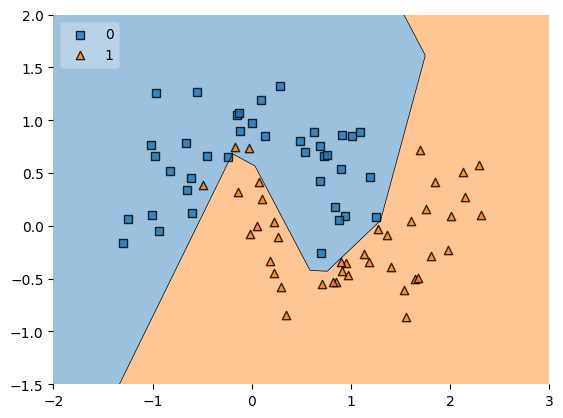

In [32]:
plot_decision_regions(X_train, y_train.astype('int'), clf=model4, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

## Loss Plot

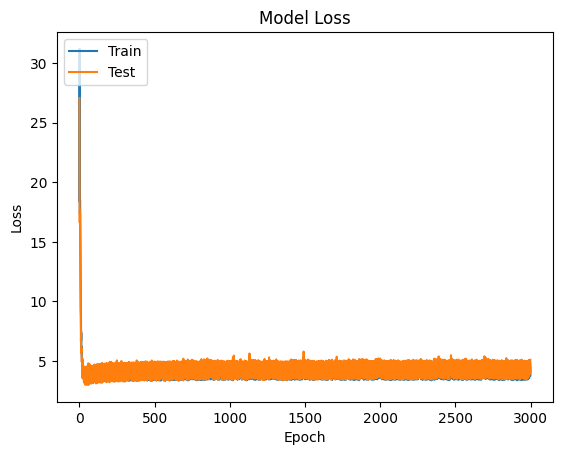

In [33]:
plt.plot(history4.history['loss'])
plt.plot(history4.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

## Accuracy Plot

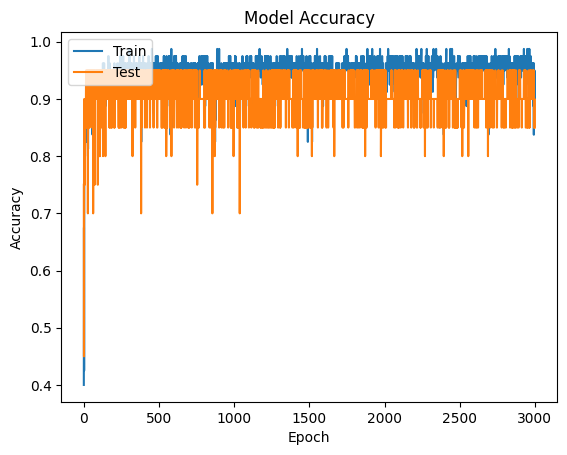

In [34]:
plt.plot(history4.history['accuracy'])
plt.plot(history4.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()